# AI212 Hatchery Linear Regression: OLS vs Bayesian Regression

This notebook compares non-Bayesian and Bayesian linear regression for the hatchery data in `Hatch_Model.xlsx`.

It implements the requested workflow:

1. Load `Hatch_Model.xlsx`, sheet `DB`, columns `B:P, AE`
2. Normalize, clean, de-duplicate, and derive `CLEAN_CHICKS_RATIO = CLEAN_CHICKS / EGGSET`
3. Fit OLS regression and report estimates, 95% confidence intervals, and training RMSE
4. Fit Bayesian linear regression with a weak/non-informative Normal-Inverse-Gamma prior
5. Fit Bayesian linear regression with an informative prior centered at standardized OLS estimates
6. Compare point estimates, confidence intervals, credible intervals, and posterior predictive summaries
7. Evaluate model complexity using 5-fold cross-validation, 0.632 bootstrap, AIC, and WAIC

The response is the clean chick hatch ratio:

\[
Y_i = \frac{\text{CLEAN\_CHICKS}_i}{\text{EGGSET}_i}
\]

`EGGSET` is used only as the denominator of the response and is not used as a regression predictor.

No engineered predictor features are used. The regression predictors are raw numeric columns from the cleaned candidate pool.

In [1]:
# Cell 1 — Imports and settings

import os
import re
import math
import json
import warnings
from pathlib import Path

os.environ.setdefault("MPLCONFIGDIR", str(Path.cwd() / ".matplotlib_cache"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import stats
from scipy.special import logsumexp

from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

import statsmodels.api as sm

warnings.filterwarnings("ignore")

RANDOM_STATE = 212
rng = np.random.default_rng(RANDOM_STATE)

# Works whether the notebook is opened from the project root, this folder, or a nearby working directory.
SEARCH_BASES = [Path.cwd(), *Path.cwd().parents]
DATA_CANDIDATES = []
for base in SEARCH_BASES:
    DATA_CANDIDATES.extend([
        base / "Hatch_Model.xlsx",
        base / "Bayesian_non_Bayesian" / "Hatch_Model.xlsx",
    ])
DATA_CANDIDATES.extend([
    Path("/Users/elyjunpates/Downloads/AI212/Problem Set/Bayesian_non_Bayesian/Hatch_Model.xlsx"),
    Path("/mnt/data/Hatch_Model.xlsx"),
])
DATA_PATH = next((p for p in DATA_CANDIDATES if p.exists()), DATA_CANDIDATES[0])
SHEET_NAME = "DB"
OUTPUT_DIR = DATA_PATH.parent / "hatch_outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Data path:", DATA_PATH.resolve())
print("Data path exists:", DATA_PATH.exists())
print("Output folder:", OUTPUT_DIR.resolve())

Data path: /Users/elyjunpates/Downloads/AI212/Problem Set/Bayesian_non_Bayesian/Hatch_Model.xlsx
Data path exists: True
Output folder: /Users/elyjunpates/Downloads/AI212/Problem Set/Bayesian_non_Bayesian/hatch_outputs


## Cell 2 — Load, normalize, and clean

The data loading follows the stated pipeline:

- Load sheet `DB`, columns `B:P, AE`
- Normalize headers using canonical names such as `WEEK_NO` and `CLEAN_CHICKS`
- Remove summary rows where `HY` contains `GRAND TOTAL`
- Convert date and numeric columns
- Keep rows with non-null `EGGSET`, `CLEAN_CHICKS`, `AGE`, `GRP`, and `S.P.`, with `EGGSET > 0`
- Remove duplicate records
- Derive `CLEAN_CHICKS_RATIO` and `CLEAN_CHICKS_PCT`
- Keep finite target values in `[0, 1]`
- Sort by available date columns

In [2]:
# Cell 2 — Load, normalize, and clean

def normalize_header(col):
    '''Normalize headers so variants such as WEEK NO., Week No, and WEEKNO map together.'''
    return re.sub(r"[^A-Z0-9]", "", str(col).strip().upper())


CANONICAL_MAP = {
    "HY": "HY",
    "LOCATION": "LOCATION",
    "WEEKNO": "WEEK_NO",
    "WEEK": "WEEK_NO",
    "HATCHDATE": "HATCH_DATE",
    "DATESET": "DATE_SET",
    "FARMSOURCE": "FARM_SOURCE",
    "LINE": "LINE",
    "B": "B",
    "H": "H",
    "STRAIN": "STRAIN",
    "PRODNDATE": "PRODN_DATE",
    "PRODUCTIONDATE": "PRODN_DATE",
    "AGE": "AGE",
    "GRP": "GRP",
    "SP": "S.P.",
    "STORAGEPERIOD": "S.P.",
    "EGGSET": "EGGSET",
    "CLEANCHICKS": "CLEAN_CHICKS",
}


def canonicalize_columns(frame):
    renamed = {}
    for col in frame.columns:
        key = normalize_header(col)
        renamed[col] = CANONICAL_MAP.get(key, str(col).strip())
    return frame.rename(columns=renamed)


def load_and_clean_hatch_model(path=DATA_PATH, sheet_name=SHEET_NAME):
    raw = pd.read_excel(
        path,
        sheet_name=sheet_name,
        usecols="B:P,AE",
        engine="openpyxl",
    )

    frame = canonicalize_columns(raw)
    frame = frame.dropna(how="all").copy()

    if "HY" in frame.columns:
        frame = frame[
            ~frame["HY"].astype(str).str.upper().str.contains("GRAND TOTAL", na=False)
        ].copy()

    for col in ["HATCH_DATE", "DATE_SET", "PRODN_DATE"]:
        if col in frame.columns:
            frame[col] = pd.to_datetime(frame[col], errors="coerce")

    for col in ["AGE", "GRP", "S.P.", "EGGSET", "CLEAN_CHICKS"]:
        if col in frame.columns:
            frame[col] = pd.to_numeric(frame[col], errors="coerce")

    if "WEEK_NO" in frame.columns:
        frame["WEEK_NO_RAW"] = frame["WEEK_NO"]
        frame["WEEK_NO_NUM"] = (
            frame["WEEK_NO"].astype(str).str.extract(r"(\d+)", expand=False).astype(float)
        )

    key_cols = ["EGGSET", "CLEAN_CHICKS", "AGE", "GRP", "S.P."]
    missing = [c for c in key_cols if c not in frame.columns]
    if missing:
        raise ValueError(f"Missing required columns after header normalization: {missing}")

    cleaning_counts = {
        "raw_selected_rows": len(raw),
        "after_drop_all_empty_rows": len(frame),
    }

    frame = frame.dropna(subset=key_cols).copy()
    cleaning_counts["after_core_non_null_filter"] = len(frame)

    frame = frame[frame["EGGSET"] > 0].copy()
    cleaning_counts["after_positive_eggset_filter"] = len(frame)

    before_dedup = len(frame)
    frame = frame.drop_duplicates().copy()
    cleaning_counts["duplicates_removed"] = before_dedup - len(frame)
    cleaning_counts["after_deduplication"] = len(frame)

    frame["CLEAN_CHICKS_RATIO"] = frame["CLEAN_CHICKS"] / frame["EGGSET"]
    frame["CLEAN_CHICKS_PCT"] = frame["CLEAN_CHICKS_RATIO"] * 100

    frame = frame[
        np.isfinite(frame["CLEAN_CHICKS_RATIO"])
        & frame["CLEAN_CHICKS_RATIO"].between(0, 1)
    ].copy()
    cleaning_counts["after_target_bounds_filter"] = len(frame)

    sort_cols = [c for c in ["HATCH_DATE", "DATE_SET", "PRODN_DATE"] if c in frame.columns]
    if sort_cols:
        frame = frame.sort_values(sort_cols).reset_index(drop=True)

    return raw, frame, pd.Series(cleaning_counts, name="rows")


raw_df, df, cleaning_summary = load_and_clean_hatch_model()

print("Raw selected shape:", raw_df.shape)
print("Cleaned shape:", df.shape)
print("Columns:")
print(df.columns.tolist())
display(cleaning_summary.to_frame())
display(df.head())

Raw selected shape: (128066, 16)
Cleaned shape: (71773, 20)
Columns:
['HY', 'LOCATION', 'WEEK_NO', 'HATCH_DATE', 'DATE_SET', 'FARM_SOURCE', 'LINE', 'B', 'H', 'STRAIN', 'PRODN_DATE', 'AGE', 'GRP', 'S.P.', 'EGGSET', 'CLEAN_CHICKS', 'WEEK_NO_RAW', 'WEEK_NO_NUM', 'CLEAN_CHICKS_RATIO', 'CLEAN_CHICKS_PCT']


,rows
raw_selected_rows,128066
after_drop_all_empty_rows,127054
after_core_non_null_filter,96554
after_positive_eggset_filter,72118
duplicates_removed,345
after_deduplication,71773
after_target_bounds_filter,71773


,HY,LOCATION,WEEK_NO,HATCH_DATE,DATE_SET,FARM_SOURCE,LINE,B,H,STRAIN,PRODN_DATE,AGE,GRP,S.P.,EGGSET,CLEAN_CHICKS,WEEK_NO_RAW,WEEK_NO_NUM,CLEAN_CHICKS_RATIO,CLEAN_CHICKS_PCT
0,GPH,MINDANAO,20-2,2020-01-02,2019-12-12,GP17,FL,3,2D,CO,2019-12-01,47.0,5.0,11.0,248.0,160.0,20-2,20.0,0.645161,64.516129
1,GPH,MINDANAO,20-2,2020-01-02,2019-12-12,GP17,FL,3,3D,CO,2019-12-01,47.0,5.0,11.0,134.0,86.0,20-2,20.0,0.641791,64.179104
2,GPH,MINDANAO,20-2,2020-01-02,2019-12-12,GP17,FL,3,4D,CO,2019-12-01,47.0,5.0,11.0,31.0,22.0,20-2,20.0,0.709677,70.967742
3,GPH,MINDANAO,20-2,2020-01-02,2019-12-12,GP9,FL,1,2D,CO,2019-12-01,32.0,2.0,11.0,619.0,486.0,20-2,20.0,0.785137,78.513732
4,GPH,MINDANAO,20-2,2020-01-02,2019-12-12,GP9,FL,1,3D,CO,2019-12-01,32.0,2.0,11.0,529.0,440.0,20-2,20.0,0.831758,83.175803


## Cell 3 — Choose response and predictors

Response:

\[
Y_i = \text{CLEAN\_CHICKS\_RATIO}_i = \frac{\text{CLEAN\_CHICKS}_i}{\text{EGGSET}_i}
\]

`EGGSET` is not included as a predictor because it is already used as the denominator of the response. `CLEAN_CHICKS` is also excluded because it is the numerator of the response.

The raw candidate predictor pool comes from the cleaned hatchery columns:

`HY`, `LOCATION`, `WEEK_NO`, `HATCH_DATE`, `DATE_SET`, `FARM_SOURCE`, `LINE`, `B`, `H`, `STRAIN`, `PRODN_DATE`, `AGE`, `GRP`, and `S.P.`

No feature-engineered predictors are used. Categorical and date fields remain valid raw candidate variables, but they are not directly used in this numeric linear-regression model because encoding or date transformations would be feature engineering. The usable raw numeric predictors are selected from the candidate pool and capped at five predictors for the assignment.

In [3]:
# Cell 3 — Response and predictors

response = "CLEAN_CHICKS_RATIO"

raw_candidate_predictors = [
    "HY", "LOCATION", "WEEK_NO", "HATCH_DATE", "DATE_SET",
    "FARM_SOURCE", "LINE", "B", "H", "STRAIN",
    "PRODN_DATE", "AGE", "GRP", "S.P.",
]

excluded_from_predictors = [
    "EGGSET",                 # denominator of the response
    "CLEAN_CHICKS",           # numerator of the response
    "CLEAN_CHICKS_RATIO",     # response
    "CLEAN_CHICKS_PCT",       # response on percentage scale
]

available_raw_candidates = [c for c in raw_candidate_predictors if c in df.columns]
categorical_candidates = [
    c for c in available_raw_candidates
    if c in ["HY", "LOCATION", "FARM_SOURCE", "LINE", "B", "H", "STRAIN"]
]
date_candidates = [
    c for c in available_raw_candidates
    if c in ["WEEK_NO", "HATCH_DATE", "DATE_SET", "PRODN_DATE"]
]

# Raw numeric predictors only. No date-derived, week-derived, or encoded categorical features are used.
raw_numeric_candidates = [
    c for c in available_raw_candidates
    if c not in categorical_candidates + date_candidates + excluded_from_predictors
    and pd.api.types.is_numeric_dtype(df[c])
]

candidate_screen = df[[response] + raw_numeric_candidates].dropna().copy()
rank_rows = []
for col in raw_numeric_candidates:
    if candidate_screen[col].nunique(dropna=True) <= 1:
        continue
    rho = candidate_screen[[response, col]].corr(method="spearman").iloc[0, 1]
    rank_rows.append({
        "candidate_feature": col,
        "abs_spearman_corr_with_response": abs(rho),
        "spearman_corr_with_response": rho,
    })

predictor_ranking = (
    pd.DataFrame(rank_rows)
    .sort_values("abs_spearman_corr_with_response", ascending=False)
    .reset_index(drop=True)
)

max_predictors = 5
collinearity_threshold = 0.98
predictors = []
skipped_for_collinearity = []
for candidate in predictor_ranking["candidate_feature"]:
    if len(predictors) >= max_predictors:
        break
    if not predictors:
        predictors.append(candidate)
        continue
    corr_with_selected = df[predictors + [candidate]].corr().loc[predictors, candidate].abs()
    max_corr = float(corr_with_selected.max())
    if max_corr >= collinearity_threshold:
        skipped_for_collinearity.append({
            "candidate_feature": candidate,
            "max_abs_corr_with_selected": max_corr,
        })
        continue
    predictors.append(candidate)

skipped_for_collinearity = pd.DataFrame(skipped_for_collinearity)

model_df = df.dropna(subset=[response] + predictors).copy()

X = model_df[predictors]
y = model_df[response]

predictor_metadata = {
    "raw_candidate_predictors": available_raw_candidates,
    "excluded_from_predictors": excluded_from_predictors,
    "categorical_candidates_not_encoded": categorical_candidates,
    "date_candidates_not_engineered": date_candidates,
    "raw_numeric_candidates": raw_numeric_candidates,
    "selected_predictors": predictors,
    "skipped_for_collinearity": skipped_for_collinearity.to_dict(orient="records"),
}

print("Modeling shape:", model_df.shape)
print("Response:", response)
print("Raw candidate predictors:", available_raw_candidates)
print("Excluded from predictors:", excluded_from_predictors)
print("Categorical candidates not encoded:", categorical_candidates)
print("Date/week candidates not engineered:", date_candidates)
print("Raw numeric candidates:", raw_numeric_candidates)
print("Selected predictors:", predictors)
print("Skipped for collinearity:")
display(skipped_for_collinearity)
display(predictor_ranking)
print(y.describe())

Modeling shape: (71773, 20)
Response: CLEAN_CHICKS_RATIO
Raw candidate predictors: ['HY', 'LOCATION', 'WEEK_NO', 'HATCH_DATE', 'DATE_SET', 'FARM_SOURCE', 'LINE', 'B', 'H', 'STRAIN', 'PRODN_DATE', 'AGE', 'GRP', 'S.P.']
Excluded from predictors: ['EGGSET', 'CLEAN_CHICKS', 'CLEAN_CHICKS_RATIO', 'CLEAN_CHICKS_PCT']
Categorical candidates not encoded: ['HY', 'LOCATION', 'FARM_SOURCE', 'LINE', 'B', 'H', 'STRAIN']
Date/week candidates not engineered: ['WEEK_NO', 'HATCH_DATE', 'DATE_SET', 'PRODN_DATE']
Raw numeric candidates: ['AGE', 'GRP', 'S.P.']
Selected predictors: ['AGE', 'GRP', 'S.P.']
Skipped for collinearity:


""


,candidate_feature,abs_spearman_corr_with_response,spearman_corr_with_response
0,AGE,0.640056,-0.640056
1,GRP,0.638158,-0.638158
2,S.P.,0.097023,-0.097023


count    71773.000000
mean         0.607413
std          0.177321
min          0.000000
25%          0.491939
50%          0.641935
75%          0.750000
max          1.000000
Name: CLEAN_CHICKS_RATIO, dtype: float64


,count,mean,std,min,25%,50%,75%,max
CLEAN_CHICKS_RATIO,71773.0,0.607413,0.177321,0.0,0.491939,0.641935,0.75,1.0
CLEAN_CHICKS,71773.0,849.532261,855.319497,0.0,178.000000,560.000000,1288.00,16943.0
EGGSET,71773.0,1273.077634,1105.357999,1.0,366.000000,980.000000,1957.00,27114.0
AGE,71773.0,44.808911,11.217721,23.0,35.000000,44.000000,54.00,73.0
GRP,71773.0,4.738035,1.904269,2.0,4.000000,4.000000,6.00,9.0
S.P.,71773.0,10.594318,4.057717,1.0,8.000000,11.000000,14.00,26.0


,CLEAN_CHICKS_RATIO,AGE,GRP,S.P.
CLEAN_CHICKS_RATIO,1.000000,-0.643438,-0.639802,-0.098692
AGE,-0.643438,1.000000,0.978046,-0.120853
GRP,-0.639802,0.978046,1.000000,-0.122373
S.P.,-0.098692,-0.120853,-0.122373,1.000000


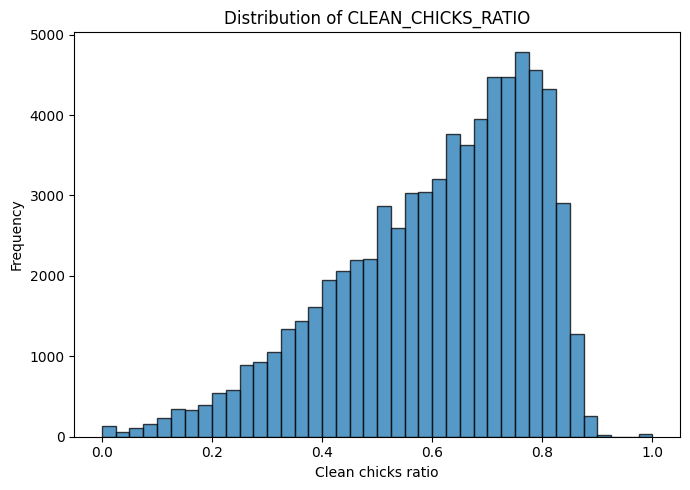

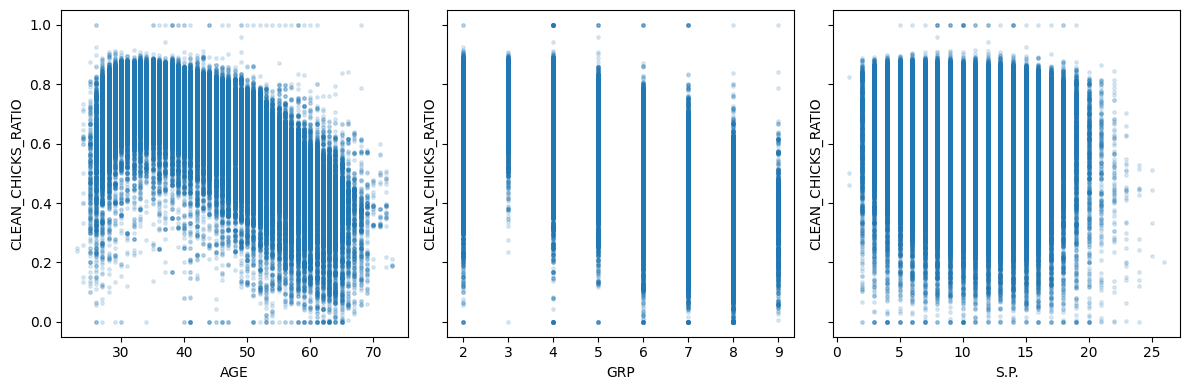

In [4]:
# Cell 4 — EDA summary tables and plots

eda_cols = [response, "CLEAN_CHICKS", "EGGSET"] + predictors
eda_cols = list(dict.fromkeys([c for c in eda_cols if c in model_df.columns]))

summary = model_df[eda_cols].describe().T
correlations = model_df[[response] + predictors].corr()

summary.to_csv(OUTPUT_DIR / "eda_summary.csv")
correlations.to_csv(OUTPUT_DIR / "correlations.csv")
cleaning_summary.to_csv(OUTPUT_DIR / "cleaning_summary.csv")

display(summary)
display(correlations)

plt.figure(figsize=(7, 5))
plt.hist(model_df[response], bins=40, edgecolor="black", alpha=0.75)
plt.xlabel("Clean chicks ratio")
plt.ylabel("Frequency")
plt.title("Distribution of CLEAN_CHICKS_RATIO")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "response_histogram.png", dpi=150)
plt.show()

fig, axes = plt.subplots(1, len(predictors), figsize=(4 * len(predictors), 4), sharey=True)
if len(predictors) == 1:
    axes = [axes]
for ax, col in zip(axes, predictors):
    ax.scatter(model_df[col], model_df[response], s=6, alpha=0.15)
    ax.set_xlabel(col)
    ax.set_ylabel(response)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "eda_predictor_scatterplots.png", dpi=150)
plt.show()

## Cell 5 — OLS regression

The OLS model is:

\[
Y = X\boldsymbol\beta + \boldsymbol\varepsilon
\]

where:

\[
\boldsymbol\varepsilon \sim \mathcal N(\mathbf 0, \sigma^2 I)
\]

OLS estimates:

\[
\widehat{\boldsymbol\beta}
=
(X^TX)^{-1}X^TY
\]


In [5]:
# Cell 5 — OLS regression using statsmodels

X_ols = sm.add_constant(X, has_constant="add")
ols_model = sm.OLS(y, X_ols).fit()

print(ols_model.summary())

ols_pred_train = ols_model.predict(X_ols)
ols_train_rmse = math.sqrt(mean_squared_error(y, ols_pred_train))

ols_ci = ols_model.conf_int(alpha=0.05)
ols_table = pd.DataFrame({
    "term": ["Intercept" if t == "const" else t for t in ols_model.params.index],
    "estimate": ols_model.params.values,
    "ci_95_low": ols_ci[0].values,
    "ci_95_high": ols_ci[1].values,
    "p_value": ols_model.pvalues.values,
})

scaler_ols = StandardScaler()
X_scaled_for_ols = scaler_ols.fit_transform(X)
X_ols_std = sm.add_constant(X_scaled_for_ols, has_constant="add")
ols_std_model = sm.OLS(y, X_ols_std).fit()
ols_std_ci = ols_std_model.conf_int(alpha=0.05)
ols_std_table = pd.DataFrame({
    "term": ["Intercept"] + predictors,
    "estimate": ols_std_model.params.values,
    "ci_95_low": ols_std_ci[:, 0] if isinstance(ols_std_ci, np.ndarray) else ols_std_ci[0].values,
    "ci_95_high": ols_std_ci[:, 1] if isinstance(ols_std_ci, np.ndarray) else ols_std_ci[1].values,
    "std_error": ols_std_model.bse,
})

ols_table.to_csv(OUTPUT_DIR / "ols_coefficients.csv", index=False)
ols_std_table.to_csv(OUTPUT_DIR / "ols_coefficients_standardized.csv", index=False)

print("OLS training RMSE:", ols_train_rmse)
print("OLS AIC:", ols_model.aic)
display(ols_table)
display(ols_std_table)

                            OLS Regression Results                            
Dep. Variable:     CLEAN_CHICKS_RATIO   R-squared:                       0.449
Model:                            OLS   Adj. R-squared:                  0.448
Method:                 Least Squares   F-statistic:                 1.946e+04
Date:                Sun, 31 May 2026   Prob (F-statistic):               0.00
Time:                        22:25:45   Log-Likelihood:                 43669.
No. Observations:               71773   AIC:                        -8.733e+04
Df Residuals:                   71769   BIC:                        -8.729e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.0969      0.004    262.658      0.0

,term,estimate,ci_95_low,ci_95_high,p_value
0,Intercept,1.096870,1.088685,1.105055,0.000000e+00
1,AGE,-0.006513,-0.006925,-0.006101,3.039618e-209
2,GRP,-0.024107,-0.026535,-0.021679,4.077125e-84
3,S.P.,-0.007873,-0.008112,-0.007634,0.000000e+00


,term,estimate,ci_95_low,ci_95_high,std_error
const,Intercept,0.607413,0.606450,0.608376,0.000492
x1,AGE,-0.073057,-0.077680,-0.068434,0.002359
x2,GRP,-0.045906,-0.050530,-0.041282,0.002359
x3,S.P.,-0.031947,-0.032918,-0.030976,0.000495


count    7.177300e+04
mean    -9.535546e-16
std      1.316817e-01
min     -8.296562e-01
25%     -7.328126e-02
50%      2.218185e-02
75%      9.595669e-02
max      6.259411e-01
dtype: float64

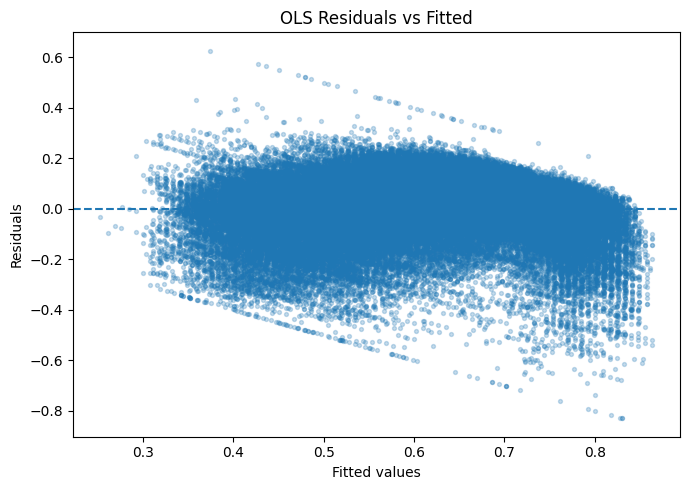

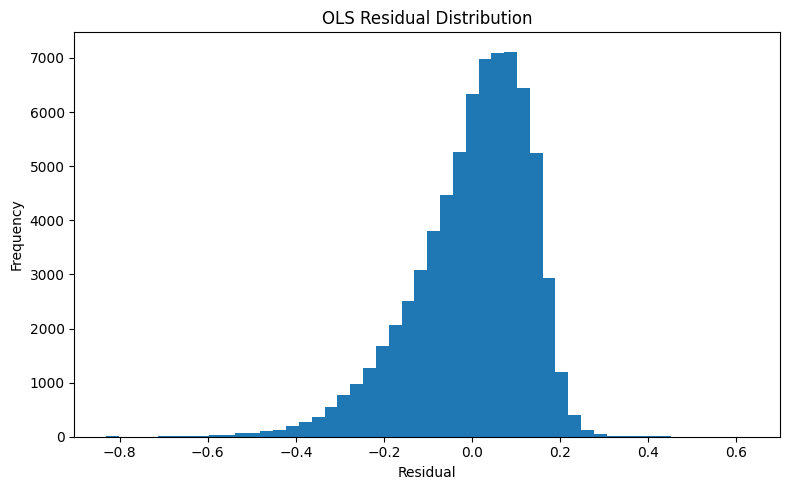

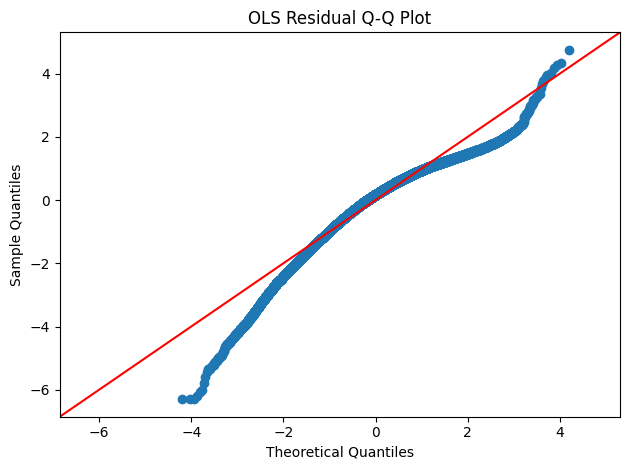

In [6]:
# Cell 6 — OLS residual diagnostics

resid = y - ols_pred_train

resid_summary = pd.Series(resid).describe()
resid_summary.to_csv(OUTPUT_DIR / "ols_residual_summary.csv")
display(resid_summary)

plt.figure(figsize=(7, 5))
plt.scatter(ols_pred_train, resid, alpha=0.25, s=8)
plt.axhline(0, linestyle="--")
plt.xlabel("Fitted values")
plt.ylabel("Residuals")
plt.title("OLS Residuals vs Fitted")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "ols_residuals_vs_fitted.png", dpi=150)
plt.savefig(OUTPUT_DIR / "ols_residuals.png", dpi=150)
plt.show()

plt.figure(figsize=(8, 5))
plt.hist(resid, bins=50)
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.title("OLS Residual Distribution")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "ols_residual_histogram.png", dpi=150)
plt.show()

sm.qqplot(resid, line="45", fit=True)
plt.title("OLS Residual Q-Q Plot")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "ols_residual_qqplot.png", dpi=150)
plt.show()

## Cell 7 — Bayesian linear regression with weak/non-informative prior

The Bayesian model uses the Gaussian likelihood:

\[
Y\mid X,\boldsymbol\beta,\sigma^2 \sim \mathcal N(X\boldsymbol\beta,\sigma^2I)
\]

For computational reliability, this notebook uses the conjugate Normal-Inverse-Gamma formulation:

\[
\boldsymbol\beta\mid\sigma^2 \sim \mathcal N(\boldsymbol m_0,\sigma^2V_0),
\qquad
\sigma^2 \sim \operatorname{InverseGamma}(a_0,b_0)
\]

The weak/non-informative prior is implemented with:

\[
\boldsymbol m_0=\mathbf 0,\quad V_0=1000^2 I,\quad a_0=b_0=0.001
\]

Predictors are standardized before Bayesian fitting. Tables are reported both on the standardized scale and transformed back to the original predictor scale for direct comparison with OLS.

In [7]:
# Cell 7 — Bayesian regression helper functions

def rmse(y_true, y_pred):
    return math.sqrt(mean_squared_error(y_true, y_pred))


def make_design_matrix(X_raw, scaler=None):
    if scaler is None:
        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(X_raw)
    else:
        X_scaled = scaler.transform(X_raw)
    X_design = np.column_stack([np.ones(X_scaled.shape[0]), X_scaled])
    return X_design, scaler


def transform_beta_samples_to_original_scale(beta_samples_std, scaler, predictor_names):
    samples = np.asarray(beta_samples_std)
    out = np.empty_like(samples)
    means = scaler.mean_
    scales = scaler.scale_
    out[:, 1:] = samples[:, 1:] / scales
    out[:, 0] = samples[:, 0] - np.sum(samples[:, 1:] * means / scales, axis=1)
    return pd.DataFrame(out, columns=["Intercept"] + list(predictor_names))


def summarize_samples(samples_df, prefix=""):
    rows = []
    for term in samples_df.columns:
        values = samples_df[term].to_numpy()
        rows.append({
            "term": term,
            f"{prefix}mean": float(np.mean(values)),
            f"{prefix}cred_95_low": float(np.quantile(values, 0.025)),
            f"{prefix}cred_95_high": float(np.quantile(values, 0.975)),
        })
    return pd.DataFrame(rows)


def fit_bayesian_nig(
    X_raw,
    y_raw,
    predictor_names=None,
    prior_mean=None,
    prior_sd=1000.0,
    a0=0.001,
    b0=0.001,
    n_samples=4000,
    random_state=RANDOM_STATE,
):
    '''
    Fit conjugate Bayesian linear regression.

    Inputs:
    - X_raw: predictor dataframe
    - y_raw: response vector
    - prior_mean: prior mean for beta including intercept; defaults to zero
    - prior_sd: scalar or vector prior standard deviation for beta
    - a0, b0: Inverse-Gamma prior parameters for sigma^2
    - n_samples: posterior draws used for original-scale intervals and WAIC

    Outputs:
    - posterior means and 95% credible intervals on standardized and original scales
    - posterior predictive summaries on the training data
    - posterior draws for beta and sigma^2
    '''
    if predictor_names is None:
        predictor_names = list(X_raw.columns)

    X_design, scaler = make_design_matrix(X_raw)
    y_vec = np.asarray(y_raw, dtype=float).reshape(-1, 1)
    n, p = X_design.shape

    if prior_mean is None:
        m0 = np.zeros((p, 1))
    else:
        m0 = np.asarray(prior_mean, dtype=float).reshape(-1, 1)

    prior_sd_vec = np.broadcast_to(np.asarray(prior_sd, dtype=float), (p,))
    V0 = np.diag(prior_sd_vec ** 2)
    V0_inv = np.linalg.inv(V0)

    XtX = X_design.T @ X_design
    Xty = X_design.T @ y_vec

    Vn = np.linalg.inv(V0_inv + XtX)
    mn = Vn @ (V0_inv @ m0 + Xty)
    an = a0 + n / 2
    bn = (
        b0
        + 0.5
        * (
            y_vec.T @ y_vec
            + m0.T @ V0_inv @ m0
            - mn.T @ np.linalg.inv(Vn) @ mn
        )
    ).item()

    terms = ["Intercept"] + list(predictor_names)
    df_t = 2 * an
    tcrit = stats.t.ppf(0.975, df=df_t)
    marginal_scale = np.sqrt((bn / an) * np.diag(Vn))

    standardized_table = pd.DataFrame({
        "term": terms,
        "posterior_mean": mn.flatten(),
        "credible_95_low": mn.flatten() - tcrit * marginal_scale,
        "credible_95_high": mn.flatten() + tcrit * marginal_scale,
    })

    local_rng = np.random.default_rng(random_state)
    sigma2_samples = stats.invgamma(a=an, scale=bn).rvs(size=n_samples, random_state=local_rng)
    # Numerical guard for nearly collinear selected predictors.
    jitter = 1e-12
    for _ in range(8):
        try:
            L = np.linalg.cholesky(Vn + jitter * np.eye(p))
            break
        except np.linalg.LinAlgError:
            jitter *= 10
    else:
        eigvals, eigvecs = np.linalg.eigh(Vn)
        eigvals = np.clip(eigvals, 1e-10, None)
        L = eigvecs @ np.diag(np.sqrt(eigvals))

    z = local_rng.normal(size=(n_samples, p))
    beta_samples_std = mn.flatten() + (z @ L.T) * np.sqrt(sigma2_samples)[:, None]
    beta_samples_original = transform_beta_samples_to_original_scale(
        beta_samples_std, scaler, predictor_names
    )
    original_table = summarize_samples(beta_samples_original)

    fitted = (X_design @ mn).flatten()
    train_rmse = rmse(y_raw, fitted)

    x_v_x = np.einsum("ij,jk,ik->i", X_design, Vn, X_design)
    pred_scale = np.sqrt((bn / an) * (1 + x_v_x))
    pred_low = fitted - tcrit * pred_scale
    pred_high = fitted + tcrit * pred_scale

    ppc = pd.DataFrame([{
        "actual_mean": float(np.mean(y_raw)),
        "predicted_mean": float(np.mean(fitted)),
        "actual_sd": float(np.std(y_raw, ddof=1)),
        "residual_sd": float(np.std(np.asarray(y_raw) - fitted, ddof=1)),
        "rmse": float(train_rmse),
        "posterior_predictive_95_coverage": float(np.mean((y_raw >= pred_low) & (y_raw <= pred_high))),
        "posterior_predictive_95_width_mean": float(np.mean(pred_high - pred_low)),
    }])

    return {
        "terms": terms,
        "scaler": scaler,
        "X_design": X_design,
        "mn": mn.flatten(),
        "Vn": Vn,
        "an": an,
        "bn": bn,
        "standardized_table": standardized_table,
        "original_table": original_table,
        "beta_samples_std": beta_samples_std,
        "beta_samples_original": beta_samples_original,
        "sigma2_samples": sigma2_samples,
        "fitted": fitted,
        "rmse": train_rmse,
        "ppc": ppc,
    }


bayes_noninf = fit_bayesian_nig(
    X,
    y,
    predictor_names=predictors,
    prior_mean=None,
    prior_sd=1000.0,
    a0=0.001,
    b0=0.001,
    n_samples=4000,
    random_state=RANDOM_STATE,
)

bayes_noninf_table = bayes_noninf["standardized_table"]
bayes_noninf_original_table = bayes_noninf["original_table"]
bayes_noninf_rmse = bayes_noninf["rmse"]

bayes_noninf_table.to_csv(OUTPUT_DIR / "bayesian_noninformative_coefficients_standardized.csv", index=False)
bayes_noninf_original_table.to_csv(OUTPUT_DIR / "bayesian_noninformative_coefficients_original_scale.csv", index=False)

print("Bayesian non-informative training RMSE:", bayes_noninf_rmse)
display(bayes_noninf_table)
display(bayes_noninf_original_table)

Bayesian non-informative training RMSE: 0.13168081717328572


,term,posterior_mean,credible_95_low,credible_95_high
0,Intercept,0.607413,0.606450,0.608376
1,AGE,-0.073057,-0.077680,-0.068434
2,GRP,-0.045906,-0.050530,-0.041282
3,S.P.,-0.031947,-0.032918,-0.030976


,term,mean,cred_95_low,cred_95_high
0,Intercept,1.096833,1.089023,1.104845
1,AGE,-0.006510,-0.006920,-0.006106
2,GRP,-0.024129,-0.026455,-0.021737
3,S.P.,-0.007873,-0.008112,-0.007635


,prior,actual_mean,predicted_mean,actual_sd,residual_sd,rmse,posterior_predictive_95_coverage,posterior_predictive_95_width_mean
0,noninformative,0.607413,0.607413,0.177321,0.131682,0.131681,0.952029,0.516203


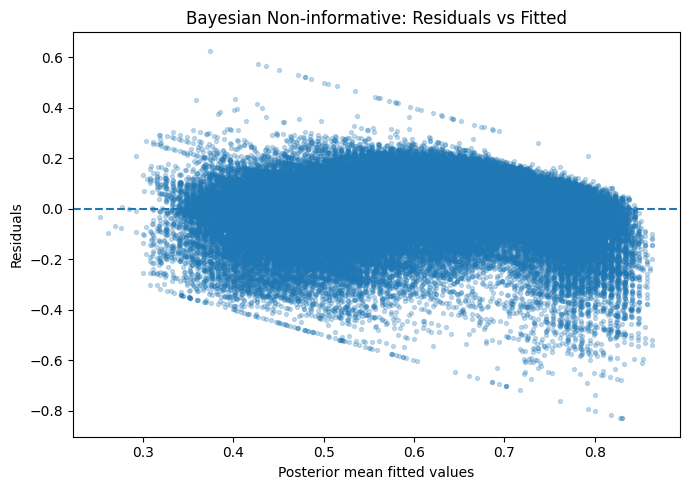

In [8]:
# Cell 8 — Posterior predictive check for non-informative Bayesian model

ppc_noninf = bayes_noninf["ppc"].copy()
ppc_noninf.insert(0, "prior", "noninformative")
ppc_noninf.to_csv(OUTPUT_DIR / "posterior_predictive_check_noninformative.csv", index=False)
display(ppc_noninf)

plt.figure(figsize=(7, 5))
plt.scatter(bayes_noninf["fitted"], y - bayes_noninf["fitted"], alpha=0.25, s=8)
plt.axhline(0, linestyle="--")
plt.xlabel("Posterior mean fitted values")
plt.ylabel("Residuals")
plt.title("Bayesian Non-informative: Residuals vs Fitted")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "bayesian_noninformative_residuals_vs_fitted.png", dpi=150)
plt.show()

## Cell 9 — Bayesian regression with informative prior

The informative prior uses the standardized OLS estimates as the prior center:

\[
\boldsymbol\beta\mid\sigma^2 \sim \mathcal N(\widehat{\boldsymbol\beta}_{OLS,std}, \sigma^2V_0)
\]

The prior standard deviations are based on two OLS standard errors with a small lower bound. This makes the prior informative enough to reduce posterior uncertainty, while still allowing the data to dominate. Because the prior center is estimated from the same data, it is mainly useful here as a required demonstration of prior influence; it should not be interpreted as external domain knowledge.

In [9]:
# Cell 9 — Informative prior from standardized OLS

prior_mean_from_ols = ols_std_model.params.values.reshape(-1, 1)
informative_prior_sd = np.maximum(2.0 * np.asarray(ols_std_model.bse), 0.02)

bayes_inf = fit_bayesian_nig(
    X,
    y,
    predictor_names=predictors,
    prior_mean=prior_mean_from_ols,
    prior_sd=informative_prior_sd,
    a0=0.001,
    b0=0.001,
    n_samples=4000,
    random_state=RANDOM_STATE + 1,
)

bayes_inf_table = bayes_inf["standardized_table"]
bayes_inf_original_table = bayes_inf["original_table"]
bayes_inf_rmse = bayes_inf["rmse"]

bayes_inf_table.to_csv(OUTPUT_DIR / "bayesian_informative_coefficients_standardized.csv", index=False)
bayes_inf_original_table.to_csv(OUTPUT_DIR / "bayesian_informative_coefficients_original_scale.csv", index=False)

prior_table = pd.DataFrame({
    "term": ["Intercept"] + predictors,
    "prior_mean_from_standardized_OLS": prior_mean_from_ols.flatten(),
    "prior_sd": informative_prior_sd,
})
prior_table.to_csv(OUTPUT_DIR / "informative_prior_parameters.csv", index=False)

print("Bayesian informative training RMSE:", bayes_inf_rmse)
display(prior_table)
display(bayes_inf_table)
display(bayes_inf_original_table)

Bayesian informative training RMSE: 0.13168081717328572


,term,prior_mean_from_standardized_OLS,prior_sd
0,Intercept,0.607413,0.02
1,AGE,-0.073057,0.02
2,GRP,-0.045906,0.02
3,S.P.,-0.031947,0.02


,term,posterior_mean,credible_95_low,credible_95_high
0,Intercept,0.607413,0.606466,0.608360
1,AGE,-0.073057,-0.075956,-0.070158
2,GRP,-0.045906,-0.048806,-0.043007
3,S.P.,-0.031947,-0.032901,-0.030993


,term,mean,cred_95_low,cred_95_high
0,Intercept,1.096911,1.090833,1.103208
1,AGE,-0.006514,-0.006773,-0.006253
2,GRP,-0.024099,-0.025588,-0.022562
3,S.P.,-0.007876,-0.008109,-0.007644


In [10]:
# Cell 10 — Compare OLS, non-informative Bayesian, and informative Bayesian estimates

ols_original_compare = ols_table.rename(columns={
    "estimate": "ols_estimate",
    "ci_95_low": "ols_ci_95_low",
    "ci_95_high": "ols_ci_95_high",
})

noninf_original_compare = bayes_noninf_original_table.rename(columns={
    "mean": "bayes_noninf_mean",
    "cred_95_low": "bayes_noninf_cred_95_low",
    "cred_95_high": "bayes_noninf_cred_95_high",
})

inf_original_compare = bayes_inf_original_table.rename(columns={
    "mean": "bayes_inf_mean",
    "cred_95_low": "bayes_inf_cred_95_low",
    "cred_95_high": "bayes_inf_cred_95_high",
})

comparison_original_scale = (
    ols_original_compare[["term", "ols_estimate", "ols_ci_95_low", "ols_ci_95_high"]]
    .merge(noninf_original_compare, on="term")
    .merge(inf_original_compare, on="term")
)
comparison_original_scale["inf_minus_noninf_mean"] = (
    comparison_original_scale["bayes_inf_mean"]
    - comparison_original_scale["bayes_noninf_mean"]
)

ols_std_compare = ols_std_table.rename(columns={
    "estimate": "ols_std_estimate",
    "ci_95_low": "ols_std_ci_95_low",
    "ci_95_high": "ols_std_ci_95_high",
})
noninf_std_compare = bayes_noninf_table.rename(columns={
    "posterior_mean": "bayes_noninf_mean",
    "credible_95_low": "bayes_noninf_cred_95_low",
    "credible_95_high": "bayes_noninf_cred_95_high",
})
inf_std_compare = bayes_inf_table.rename(columns={
    "posterior_mean": "bayes_inf_mean",
    "credible_95_low": "bayes_inf_cred_95_low",
    "credible_95_high": "bayes_inf_cred_95_high",
})

comparison_standardized = (
    ols_std_compare[["term", "ols_std_estimate", "ols_std_ci_95_low", "ols_std_ci_95_high"]]
    .merge(noninf_std_compare, on="term")
    .merge(inf_std_compare, on="term")
)
comparison_standardized["inf_minus_noninf_mean"] = (
    comparison_standardized["bayes_inf_mean"]
    - comparison_standardized["bayes_noninf_mean"]
)

comparison_original_scale.to_csv(OUTPUT_DIR / "ols_bayesian_comparison_original_scale.csv", index=False)
comparison_standardized.to_csv(OUTPUT_DIR / "ols_bayesian_comparison_standardized.csv", index=False)

bayes_coefficients_standardized = pd.concat([
    bayes_noninf_table.assign(prior="noninformative"),
    bayes_inf_table.assign(prior="informative_from_OLS"),
], ignore_index=True)[["prior", "term", "posterior_mean", "credible_95_low", "credible_95_high"]]
bayes_coefficients_original_scale = pd.concat([
    bayes_noninf_original_table.assign(prior="noninformative"),
    bayes_inf_original_table.assign(prior="informative_from_OLS"),
], ignore_index=True)[["prior", "term", "mean", "cred_95_low", "cred_95_high"]]

bayes_coefficients_standardized.to_csv(OUTPUT_DIR / "bayes_coefficients_standardized.csv", index=False)
bayes_coefficients_original_scale.to_csv(OUTPUT_DIR / "bayes_coefficients_original_scale.csv", index=False)

ppc_inf = bayes_inf["ppc"].copy()
ppc_inf.insert(0, "prior", "informative_from_OLS")
ppc_summary = pd.concat([ppc_noninf, ppc_inf], ignore_index=True)
ppc_summary.to_csv(OUTPUT_DIR / "posterior_predictive_check_summary.csv", index=False)

display(comparison_original_scale)
display(comparison_standardized)
display(ppc_summary)

,term,ols_estimate,ols_ci_95_low,ols_ci_95_high,bayes_noninf_mean,bayes_noninf_cred_95_low,bayes_noninf_cred_95_high,bayes_inf_mean,bayes_inf_cred_95_low,bayes_inf_cred_95_high,inf_minus_noninf_mean
0,Intercept,1.096870,1.088685,1.105055,1.096833,1.089023,1.104845,1.096911,1.090833,1.103208,0.000078
1,AGE,-0.006513,-0.006925,-0.006101,-0.006510,-0.006920,-0.006106,-0.006514,-0.006773,-0.006253,-0.000004
2,GRP,-0.024107,-0.026535,-0.021679,-0.024129,-0.026455,-0.021737,-0.024099,-0.025588,-0.022562,0.000030
3,S.P.,-0.007873,-0.008112,-0.007634,-0.007873,-0.008112,-0.007635,-0.007876,-0.008109,-0.007644,-0.000003


,term,ols_std_estimate,ols_std_ci_95_low,ols_std_ci_95_high,bayes_noninf_mean,bayes_noninf_cred_95_low,bayes_noninf_cred_95_high,bayes_inf_mean,bayes_inf_cred_95_low,bayes_inf_cred_95_high,inf_minus_noninf_mean
0,Intercept,0.607413,0.606450,0.608376,0.607413,0.606450,0.608376,0.607413,0.606466,0.608360,8.463008e-12
1,AGE,-0.073057,-0.077680,-0.068434,-0.073057,-0.077680,-0.068434,-0.073057,-0.075956,-0.070158,-9.051537e-12
2,GRP,-0.045906,-0.050530,-0.041282,-0.045906,-0.050530,-0.041282,-0.045906,-0.048806,-0.043007,8.147372e-12
3,S.P.,-0.031947,-0.032918,-0.030976,-0.031947,-0.032918,-0.030976,-0.031947,-0.032901,-0.030993,-5.420664e-13


,prior,actual_mean,predicted_mean,actual_sd,residual_sd,rmse,posterior_predictive_95_coverage,posterior_predictive_95_width_mean
0,noninformative,0.607413,0.607413,0.177321,0.131682,0.131681,0.952029,0.516203
1,informative_from_OLS,0.607413,0.607413,0.177321,0.131682,0.131681,0.952029,0.516200


## Cell 11 — OLS model complexity using 5-fold CV and 0.632 bootstrap

We fit a sequence of OLS models with increasing complexity using the selected raw numeric predictors from Cell 3. The predictor order is data-derived: raw numeric candidates are ranked by absolute Spearman association with the response, excluding `EGGSET` and other target/leakage columns.

For each model:

- 5-fold CV is run with shuffled folds and fixed `RANDOM_STATE`.
- A 0.632 bootstrap estimate is computed as `0.368 * resubstitution RMSE + 0.632 * out-of-bag RMSE`.
- AIC is computed from the statsmodels OLS fit on the full modeling data.

In [11]:
# Cell 11 — OLS cross-validation and 0.632 bootstrap

def cv_rmse_linear(X_data, y_data, predictor_list, k=5):
    kf = KFold(n_splits=k, shuffle=True, random_state=RANDOM_STATE)
    scores = []

    for train_idx, test_idx in kf.split(X_data):
        X_train = X_data.iloc[train_idx][predictor_list]
        X_test = X_data.iloc[test_idx][predictor_list]
        y_train = y_data.iloc[train_idx]
        y_test = y_data.iloc[test_idx]

        pipe = Pipeline([
            ("scaler", StandardScaler()),
            ("model", LinearRegression()),
        ])
        pipe.fit(X_train, y_train)
        pred = pipe.predict(X_test)
        scores.append(rmse(y_test, pred))

    return float(np.mean(scores)), float(np.std(scores, ddof=1))


def bootstrap_632_rmse(X_data, y_data, predictor_list, B=100, random_state=RANDOM_STATE):
    n = len(y_data)
    local_rng = np.random.default_rng(random_state + len(predictor_list))

    full_pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("model", LinearRegression()),
    ])
    full_pipe.fit(X_data[predictor_list], y_data)
    resub_error = rmse(y_data, full_pipe.predict(X_data[predictor_list]))

    oob_errors = []
    for _ in range(B):
        boot_idx = local_rng.choice(np.arange(n), size=n, replace=True)
        oob_mask = np.ones(n, dtype=bool)
        oob_mask[boot_idx] = False
        oob_idx = np.where(oob_mask)[0]

        if len(oob_idx) == 0:
            continue

        X_boot = X_data.iloc[boot_idx][predictor_list]
        y_boot = y_data.iloc[boot_idx]
        X_oob = X_data.iloc[oob_idx][predictor_list]
        y_oob = y_data.iloc[oob_idx]

        pipe = Pipeline([
            ("scaler", StandardScaler()),
            ("model", LinearRegression()),
        ])
        pipe.fit(X_boot, y_boot)
        pred_oob = pipe.predict(X_oob)
        oob_errors.append(rmse(y_oob, pred_oob))

    bootstrap_oob = float(np.mean(oob_errors))
    error_632 = 0.368 * resub_error + 0.632 * bootstrap_oob

    return float(error_632), float(resub_error), bootstrap_oob


complexity_rows = []

for k in range(1, len(predictors) + 1):
    pred_list = predictors[:k]

    cv_mean, cv_std = cv_rmse_linear(X, y, pred_list, k=5)
    boot632, resub, boot_oob = bootstrap_632_rmse(X, y, pred_list, B=100)

    X_sm = sm.add_constant(X[pred_list], has_constant="add")
    fit = sm.OLS(y, X_sm).fit()

    complexity_rows.append({
        "k": k,
        "predictors": " + ".join(pred_list),
        "cv_rmse_mean": cv_mean,
        "cv_rmse_sd": cv_std,
        "train_rmse": resub,
        "bootstrap_632_rmse": boot632,
        "bootstrap_oob_rmse": boot_oob,
        "aic": fit.aic,
        "bic": fit.bic,
        "r2": fit.rsquared,
        "adj_r2": fit.rsquared_adj,
    })

ols_complexity = pd.DataFrame(complexity_rows)
ols_complexity.to_csv(OUTPUT_DIR / "model_complexity_ols.csv", index=False)
ols_complexity.to_csv(OUTPUT_DIR / "ols_complexity_cv_bootstrap_aic.csv", index=False)
display(ols_complexity)

,k,predictors,cv_rmse_mean,cv_rmse_sd,train_rmse,bootstrap_632_rmse,bootstrap_oob_rmse,aic,bic,r2,adj_r2
0,1,AGE,0.135736,0.001293,0.135738,0.135655,0.135607,-82978.502326,-82960.139799,0.414012,0.414004
1,2,AGE + GRP,0.135446,0.001297,0.135444,0.135431,0.135424,-83287.589362,-83260.045571,0.416546,0.416530
2,3,AGE + GRP + S.P.,0.131687,0.001138,0.131681,0.131677,0.131674,-87330.525794,-87293.800740,0.448519,0.448496


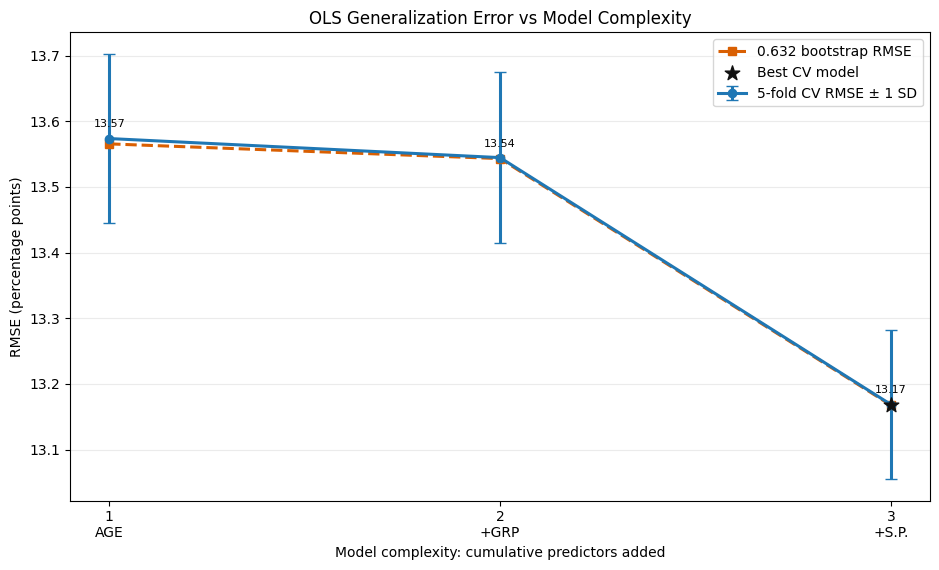

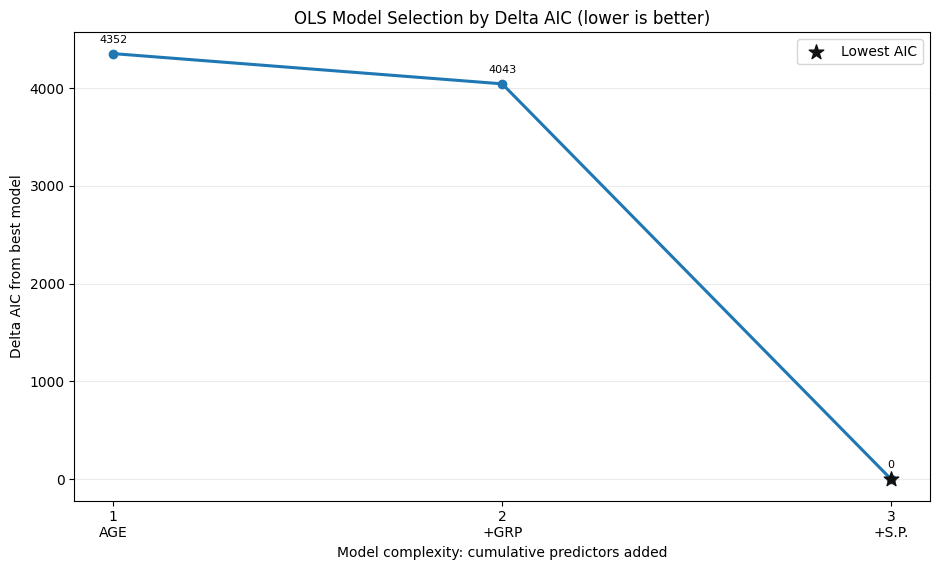

In [12]:
# Cell 12 — Plot OLS model complexity

def _complexity_tick_labels(complexity_frame):
    labels = []
    for _, row in complexity_frame.iterrows():
        parts = [part.strip() for part in row["predictors"].split("+")]
        added = parts[-1]
        labels.append(f"{int(row['k'])}\n{added if int(row['k']) == 1 else '+' + added}")
    return labels


def _annotate_values(ax, x_values, y_values, fmt="{:.2f}", dy=6):
    for x_val, y_val in zip(x_values, y_values):
        ax.annotate(
            fmt.format(y_val),
            (x_val, y_val),
            textcoords="offset points",
            xytext=(0, dy),
            ha="center",
            fontsize=8,
        )


def _mark_best(ax, x_values, y_values, label="Best"):
    best_pos = int(np.argmin(y_values))
    ax.scatter(
        [x_values.iloc[best_pos]],
        [y_values.iloc[best_pos]],
        s=120,
        marker="*",
        color="#111111",
        zorder=5,
        label=label,
    )


x = ols_complexity["k"]
tick_labels = _complexity_tick_labels(ols_complexity)

fig, ax = plt.subplots(figsize=(9.5, 5.8))
cv_rmse_pp = ols_complexity["cv_rmse_mean"] * 100
cv_rmse_sd_pp = ols_complexity["cv_rmse_sd"] * 100
boot_rmse_pp = ols_complexity["bootstrap_632_rmse"] * 100

ax.errorbar(
    x,
    cv_rmse_pp,
    yerr=cv_rmse_sd_pp,
    marker="o",
    linewidth=2.2,
    capsize=4,
    color="#1f77b4",
    label="5-fold CV RMSE ± 1 SD",
)
ax.plot(
    x,
    boot_rmse_pp,
    marker="s",
    linestyle="--",
    linewidth=2.2,
    color="#d95f02",
    label="0.632 bootstrap RMSE",
)
_mark_best(ax, x, cv_rmse_pp, "Best CV model")
_annotate_values(ax, x, cv_rmse_pp, fmt="{:.2f}", dy=8)

ax.set_xlabel("Model complexity: cumulative predictors added")
ax.set_ylabel("RMSE (percentage points)")
ax.set_title("OLS Generalization Error vs Model Complexity")
ax.set_xticks(x)
ax.set_xticklabels(tick_labels)
ax.grid(True, axis="y", alpha=0.25)
ax.legend(frameon=True)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "ols_rmse_vs_complexity.png", dpi=150)
fig.savefig(OUTPUT_DIR / "ols_complexity_rmse.png", dpi=150)
plt.show()

fig, ax = plt.subplots(figsize=(9.5, 5.8))
delta_aic = ols_complexity["aic"] - ols_complexity["aic"].min()
ax.plot(x, delta_aic, marker="o", linewidth=2.2, color="#1f77b4")
_mark_best(ax, x, delta_aic, "Lowest AIC")
_annotate_values(ax, x, delta_aic, fmt="{:.0f}", dy=8)
ax.set_xlabel("Model complexity: cumulative predictors added")
ax.set_ylabel("Delta AIC from best model")
ax.set_title("OLS Model Selection by Delta AIC (lower is better)")
ax.set_xticks(x)
ax.set_xticklabels(tick_labels)
ax.grid(True, axis="y", alpha=0.25)
ax.legend(frameon=True)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "ols_aic_vs_complexity.png", dpi=150)
plt.show()

## Cell 13 — Bayesian model complexity using 5-fold CV and WAIC

For Bayesian model complexity, each candidate model is fitted with the same weak Normal-Inverse-Gamma prior used in Cell 7.

For each model:

- 5-fold CV predicts held-out folds using the posterior mean prediction from the training fold.
- WAIC is computed from posterior draws on the full modeling data. Lower WAIC indicates better expected out-of-sample predictive performance.

This keeps the Bayesian complexity comparison aligned with the Bayesian regression model used earlier, instead of switching to a different estimator.

In [13]:
# Cell 13 — Bayesian NIG CV and WAIC

def predict_bayesian_posterior_mean(fit_result, X_new):
    X_new_design, _ = make_design_matrix(X_new, scaler=fit_result["scaler"])
    return X_new_design @ fit_result["mn"]


def cv_rmse_bayesian_nig(X_data, y_data, predictor_list, k=5):
    kf = KFold(n_splits=k, shuffle=True, random_state=RANDOM_STATE)
    scores = []

    for fold, (train_idx, test_idx) in enumerate(kf.split(X_data), start=1):
        X_train = X_data.iloc[train_idx][predictor_list]
        X_test = X_data.iloc[test_idx][predictor_list]
        y_train = y_data.iloc[train_idx]
        y_test = y_data.iloc[test_idx]

        fit = fit_bayesian_nig(
            X_train,
            y_train,
            predictor_names=predictor_list,
            prior_mean=None,
            prior_sd=1000.0,
            a0=0.001,
            b0=0.001,
            n_samples=800,
            random_state=RANDOM_STATE + 1000 * len(predictor_list) + fold,
        )
        pred = predict_bayesian_posterior_mean(fit, X_test)
        scores.append(rmse(y_test, pred))

    return float(np.mean(scores)), float(np.std(scores, ddof=1))


def compute_waic(y_true, X_design, beta_samples_std, sigma2_samples, chunk_size=5000):
    y_arr = np.asarray(y_true, dtype=float)
    beta_samples = np.asarray(beta_samples_std)
    sigma2 = np.asarray(sigma2_samples)
    n = len(y_arr)
    s = len(sigma2)
    lppd_total = 0.0
    p_waic_total = 0.0

    const = -0.5 * np.log(2 * np.pi * sigma2)
    inv_two_sigma2 = -0.5 / sigma2

    for start in range(0, n, chunk_size):
        stop = min(start + chunk_size, n)
        mu = X_design[start:stop] @ beta_samples.T
        resid2 = (y_arr[start:stop, None] - mu) ** 2
        log_lik = const[None, :] + resid2 * inv_two_sigma2[None, :]
        lppd_total += float(np.sum(logsumexp(log_lik, axis=1) - np.log(s)))
        p_waic_total += float(np.sum(np.var(log_lik, axis=1, ddof=1)))

    waic = -2 * (lppd_total - p_waic_total)
    return {
        "waic": waic,
        "lppd": lppd_total,
        "p_waic": p_waic_total,
    }


bayes_rows = []

for k in range(1, len(predictors) + 1):
    pred_list = predictors[:k]

    cv_mean, cv_std = cv_rmse_bayesian_nig(X, y, pred_list, k=5)

    full_fit = fit_bayesian_nig(
        X[pred_list],
        y,
        predictor_names=pred_list,
        prior_mean=None,
        prior_sd=1000.0,
        a0=0.001,
        b0=0.001,
        n_samples=1000,
        random_state=RANDOM_STATE + 2000 + k,
    )
    waic_info = compute_waic(
        y,
        full_fit["X_design"],
        full_fit["beta_samples_std"],
        full_fit["sigma2_samples"],
        chunk_size=5000,
    )

    bayes_rows.append({
        "k": k,
        "predictors": " + ".join(pred_list),
        "bayes_cv_rmse_mean": cv_mean,
        "bayes_cv_rmse_sd": cv_std,
        "bayes_train_rmse": full_fit["rmse"],
        "waic": waic_info["waic"],
        "lppd": waic_info["lppd"],
        "p_waic": waic_info["p_waic"],
    })

bayes_complexity = pd.DataFrame(bayes_rows)
bayes_complexity.to_csv(OUTPUT_DIR / "model_complexity_bayesian.csv", index=False)
bayes_complexity.to_csv(OUTPUT_DIR / "bayesian_complexity_cv_waic.csv", index=False)
display(bayes_complexity)

,k,predictors,bayes_cv_rmse_mean,bayes_cv_rmse_sd,bayes_train_rmse,waic,lppd,p_waic
0,1,AGE,0.135736,0.001293,0.135738,-82975.873993,41491.670626,3.733630
1,2,AGE + GRP,0.135446,0.001297,0.135444,-83284.986312,41647.120345,4.627188
2,3,AGE + GRP + S.P.,0.131687,0.001138,0.131681,-87327.586251,43669.690234,5.897109


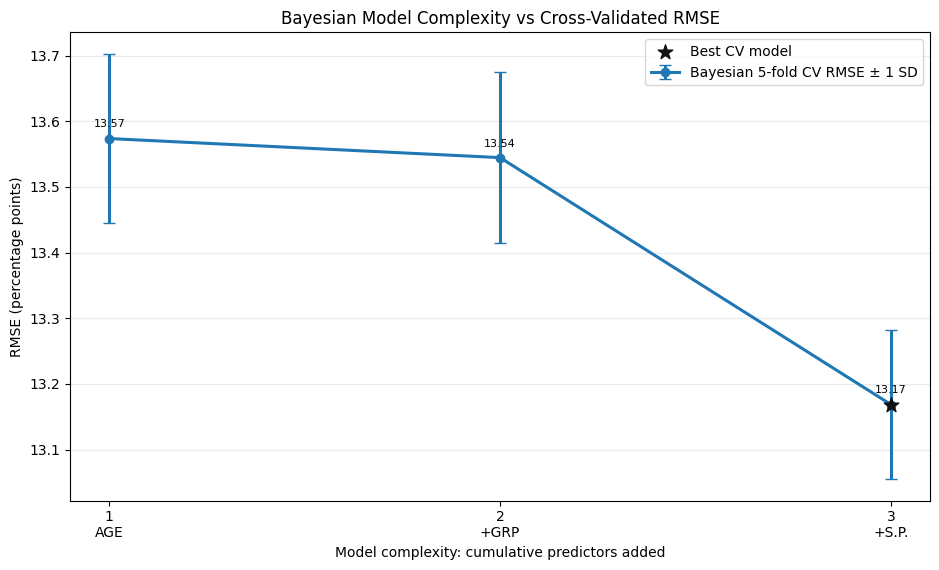

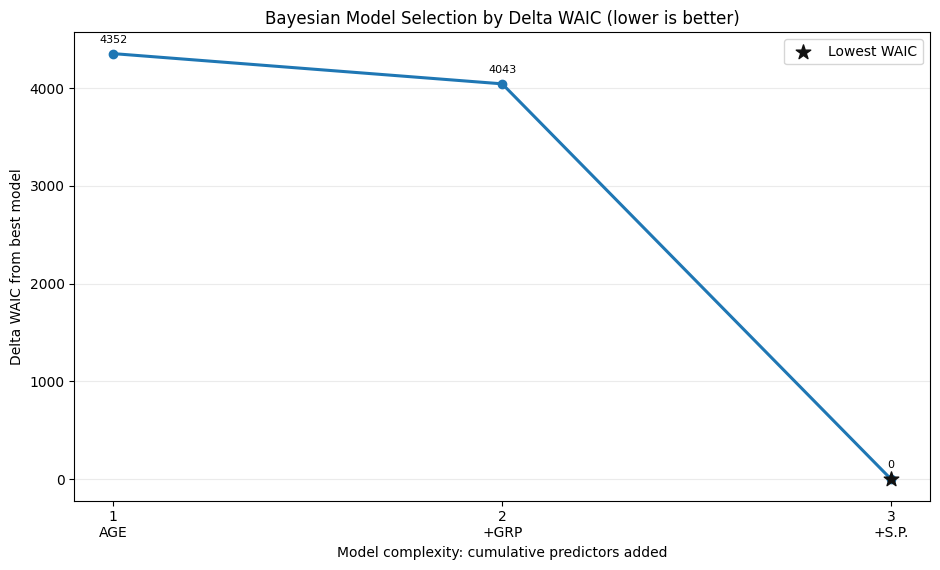

In [14]:
# Cell 14 — Plot Bayesian model complexity

x = bayes_complexity["k"]
tick_labels = _complexity_tick_labels(bayes_complexity)

fig, ax = plt.subplots(figsize=(9.5, 5.8))
bayes_cv_rmse_pp = bayes_complexity["bayes_cv_rmse_mean"] * 100
bayes_cv_rmse_sd_pp = bayes_complexity["bayes_cv_rmse_sd"] * 100

ax.errorbar(
    x,
    bayes_cv_rmse_pp,
    yerr=bayes_cv_rmse_sd_pp,
    marker="o",
    linewidth=2.2,
    capsize=4,
    color="#1f77b4",
    label="Bayesian 5-fold CV RMSE ± 1 SD",
)
_mark_best(ax, x, bayes_cv_rmse_pp, "Best CV model")
_annotate_values(ax, x, bayes_cv_rmse_pp, fmt="{:.2f}", dy=8)

ax.set_xlabel("Model complexity: cumulative predictors added")
ax.set_ylabel("RMSE (percentage points)")
ax.set_title("Bayesian Model Complexity vs Cross-Validated RMSE")
ax.set_xticks(x)
ax.set_xticklabels(tick_labels)
ax.grid(True, axis="y", alpha=0.25)
ax.legend(frameon=True)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "bayesian_complexity_rmse.png", dpi=150)
plt.show()

fig, ax = plt.subplots(figsize=(9.5, 5.8))
delta_waic = bayes_complexity["waic"] - bayes_complexity["waic"].min()
ax.plot(x, delta_waic, marker="o", linewidth=2.2, color="#1f77b4")
_mark_best(ax, x, delta_waic, "Lowest WAIC")
_annotate_values(ax, x, delta_waic, fmt="{:.0f}", dy=8)
ax.set_xlabel("Model complexity: cumulative predictors added")
ax.set_ylabel("Delta WAIC from best model")
ax.set_title("Bayesian Model Selection by Delta WAIC (lower is better)")
ax.set_xticks(x)
ax.set_xticklabels(tick_labels)
ax.grid(True, axis="y", alpha=0.25)
ax.legend(frameon=True)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "bayesian_complexity_waic.png", dpi=150)
plt.show()

## Cell 15 — Final model selection summary

This cell prints the best models according to:

- OLS 5-fold CV RMSE
- OLS 0.632 bootstrap RMSE
- OLS AIC
- Bayesian 5-fold CV RMSE
- Bayesian WAIC

Lower values are better for all five criteria.

In [15]:
# Cell 15 — Final model selection summary

best_ols_cv = ols_complexity.loc[ols_complexity["cv_rmse_mean"].idxmin()]
best_ols_boot = ols_complexity.loc[ols_complexity["bootstrap_632_rmse"].idxmin()]
best_ols_aic = ols_complexity.loc[ols_complexity["aic"].idxmin()]

best_bayes_cv = bayes_complexity.loc[bayes_complexity["bayes_cv_rmse_mean"].idxmin()]
best_bayes_waic = bayes_complexity.loc[bayes_complexity["waic"].idxmin()]

selection_summary = pd.DataFrame([
    {
        "criterion": "OLS 5-fold CV RMSE",
        "best_k": int(best_ols_cv["k"]),
        "predictors": best_ols_cv["predictors"],
        "score": best_ols_cv["cv_rmse_mean"],
    },
    {
        "criterion": "OLS 0.632 Bootstrap RMSE",
        "best_k": int(best_ols_boot["k"]),
        "predictors": best_ols_boot["predictors"],
        "score": best_ols_boot["bootstrap_632_rmse"],
    },
    {
        "criterion": "OLS AIC",
        "best_k": int(best_ols_aic["k"]),
        "predictors": best_ols_aic["predictors"],
        "score": best_ols_aic["aic"],
    },
    {
        "criterion": "Bayesian 5-fold CV RMSE",
        "best_k": int(best_bayes_cv["k"]),
        "predictors": best_bayes_cv["predictors"],
        "score": best_bayes_cv["bayes_cv_rmse_mean"],
    },
    {
        "criterion": "Bayesian WAIC",
        "best_k": int(best_bayes_waic["k"]),
        "predictors": best_bayes_waic["predictors"],
        "score": best_bayes_waic["waic"],
    },
])

selection_summary.to_csv(OUTPUT_DIR / "model_selection_summary.csv", index=False)
display(selection_summary)

delta_ols = ols_complexity["cv_rmse_mean"].shift(1) - ols_complexity["cv_rmse_mean"]
delta_bayes = bayes_complexity["bayes_cv_rmse_mean"].shift(1) - bayes_complexity["bayes_cv_rmse_mean"]
complexity_gain = pd.DataFrame({
    "k": ols_complexity["k"],
    "predictors": ols_complexity["predictors"],
    "ols_cv_rmse_improvement_from_previous": delta_ols,
    "bayes_cv_rmse_improvement_from_previous": delta_bayes,
})
complexity_gain.to_csv(OUTPUT_DIR / "model_complexity_incremental_gain.csv", index=False)
display(complexity_gain)

print("Recommended final OLS model:", best_ols_cv["predictors"])
print("Recommended final Bayesian model:", best_bayes_cv["predictors"])

,criterion,best_k,predictors,score
0,OLS 5-fold CV RMSE,3,AGE + GRP + S.P.,0.131687
1,OLS 0.632 Bootstrap RMSE,3,AGE + GRP + S.P.,0.131677
2,OLS AIC,3,AGE + GRP + S.P.,-87330.525794
3,Bayesian 5-fold CV RMSE,3,AGE + GRP + S.P.,0.131687
4,Bayesian WAIC,3,AGE + GRP + S.P.,-87327.586251


,k,predictors,ols_cv_rmse_improvement_from_previous,bayes_cv_rmse_improvement_from_previous
0,1,AGE,NaN,NaN
1,2,AGE + GRP,0.000290,0.000290
2,3,AGE + GRP + S.P.,0.003759,0.003759


Recommended final OLS model: AGE + GRP + S.P.
Recommended final Bayesian model: AGE + GRP + S.P.


## Interpretation guide

### OLS vs Bayesian regression

OLS treats the coefficient vector \(\boldsymbol\beta\) as fixed but unknown. Bayesian regression treats \(\boldsymbol\beta\) and \(\sigma^2\) as uncertain and describes them with a posterior distribution:

\[
p(\boldsymbol\beta,\sigma^2\mid D)
\propto
p(D\mid \boldsymbol\beta,\sigma^2)p(\boldsymbol\beta,\sigma^2)
\]

With a weak prior and a large dataset, the Bayesian posterior means should be very close to OLS estimates. The intervals are interpreted differently: OLS confidence intervals describe repeated-sampling behavior, while Bayesian credible intervals describe posterior probability under the model and prior.

### Non-informative prior

The weak prior uses a large coefficient variance and \(a_0=b_0=0.001\) for \(\sigma^2\). This adds little prior information, so the posterior is dominated by the hatchery data.

### Informative prior

The informative prior is centered at standardized OLS estimates. Because the prior center agrees with the data, it does not materially pull posterior means away from the weak-prior estimates. Its main visible effect is narrower uncertainty. A prior centered away from the OLS estimates would pull posterior means toward that prior center, with stronger pull when prior standard deviations are smaller or sample size is lower.

### Model complexity

Cross-validation and 0.632 bootstrap estimate generalization error. AIC and WAIC penalize model complexity. `EGGSET` is deliberately excluded because it defines the denominator of the response. No engineered predictor features are used; the tested model sequence is built from selected raw numeric predictors only.

### Practical hatchery interpretation

If the selected linear model wins but RMSE remains operationally large, the next step should be a separate model that explicitly allows feature engineering or encoding:

- one-hot or hierarchical effects for `LINE`, `LOCATION`, `STRAIN`, and farm/source fields
- date-derived calendar effects from `HATCH_DATE`, `DATE_SET`, or `PRODN_DATE`
- separate models by `LINE`, `LOCATION`, or `STRAIN`
- time-aware validation by `HATCH_DATE`
- nonlinear models such as Random Forest, Gradient Boosting, XGBoost, or GAM

In [16]:
# Cell 16 — Save compact machine-readable and text reports

results = {
    "raw_shape": list(raw_df.shape),
    "clean_shape": list(df.shape),
    "modeling_shape": list(model_df.shape),
    "columns": list(df.columns),
    "predictor_metadata": predictor_metadata,
    "predictors": predictors,
    "response": response,
    "ols_train_rmse": float(ols_train_rmse),
    "ols_r2": float(ols_model.rsquared),
    "ols_adj_r2": float(ols_model.rsquared_adj),
    "ols_aic": float(ols_model.aic),
    "ols_coefficients": ols_table.to_dict(orient="records"),
    "bayes_noninformative_rmse": float(bayes_noninf_rmse),
    "bayes_informative_rmse": float(bayes_inf_rmse),
    "bayes_noninformative_coefficients_original_scale": bayes_noninf_original_table.to_dict(orient="records"),
    "bayes_informative_coefficients_original_scale": bayes_inf_original_table.to_dict(orient="records"),
    "posterior_predictive_checks": ppc_summary.to_dict(orient="records"),
    "cv_ols": ols_complexity.to_dict(orient="records"),
    "cv_bayes": bayes_complexity.to_dict(orient="records"),
    "selection_summary": selection_summary.to_dict(orient="records"),
}

with open(OUTPUT_DIR / "results.json", "w", encoding="utf-8") as f:
    json.dump(results, f, indent=2)

report_path = OUTPUT_DIR / "summary_report.md"
with open(report_path, "w", encoding="utf-8") as f:
    f.write("# Hatch Model: Bayesian vs Non-Bayesian Linear Regression\n\n")
    f.write(f"Raw selected shape: {raw_df.shape[0]:,} rows x {raw_df.shape[1]} columns.  \n")
    f.write(f"Cleaned data shape: {df.shape[0]:,} rows x {df.shape[1]} columns.  \n")
    f.write(f"Modeling shape: {model_df.shape[0]:,} rows x {model_df.shape[1]} columns.  \n\n")
    f.write(f"Response: `{response}` = `CLEAN_CHICKS / EGGSET`.  \n")
    f.write("Excluded predictor: `EGGSET`, because it is already the response denominator.  \n")
    f.write(f"Raw candidate predictors: `{', '.join(available_raw_candidates)}`.  \n")
    f.write(f"Categorical candidates not encoded: `{', '.join(categorical_candidates)}`.  \n")
    f.write(f"Date/week candidates not engineered: `{', '.join(date_candidates)}`.  \n")
    f.write(f"Selected raw numeric predictors: `{', '.join(predictors)}`.  \n\n")
    f.write(
        f"OLS full model training RMSE: {ols_train_rmse:.6f} ratio units "
        f"({100 * ols_train_rmse:.3f} percentage points). "
        f"R2={ols_model.rsquared:.4f}; adjusted R2={ols_model.rsquared_adj:.4f}; "
        f"AIC={ols_model.aic:.2f}.  \n\n"
    )
    f.write(f"Bayesian weak-prior training RMSE: {bayes_noninf_rmse:.6f}.  \n")
    f.write(f"Bayesian informative-prior training RMSE: {bayes_inf_rmse:.6f}.  \n\n")
    f.write(
        f"Best OLS 5-fold CV: k={int(best_ols_cv['k'])}, "
        f"predictors={best_ols_cv['predictors']}, "
        f"CV RMSE={best_ols_cv['cv_rmse_mean']:.6f}.  \n"
    )
    f.write(
        f"Best OLS 0.632 bootstrap: k={int(best_ols_boot['k'])}, "
        f"predictors={best_ols_boot['predictors']}, "
        f"RMSE={best_ols_boot['bootstrap_632_rmse']:.6f}.  \n"
    )
    f.write(
        f"Best OLS AIC: k={int(best_ols_aic['k'])}, "
        f"predictors={best_ols_aic['predictors']}, "
        f"AIC={best_ols_aic['aic']:.2f}.  \n"
    )
    f.write(
        f"Best Bayesian 5-fold CV: k={int(best_bayes_cv['k'])}, "
        f"predictors={best_bayes_cv['predictors']}, "
        f"CV RMSE={best_bayes_cv['bayes_cv_rmse_mean']:.6f}.  \n"
    )
    f.write(
        f"Best Bayesian WAIC: k={int(best_bayes_waic['k'])}, "
        f"predictors={best_bayes_waic['predictors']}, "
        f"WAIC={best_bayes_waic['waic']:.2f}.  \n\n"
    )
    f.write("Conclusion: EGGSET was excluded as a predictor because it is the denominator of the response. The fitted sequence uses only selected raw numeric predictors from the raw candidate pool. Categorical and date/week raw candidates are valid predictors for a future encoded or engineered model, but were not transformed in this no-feature-engineering comparison.\n")

print("Saved report to:", report_path)
print("All outputs saved to:", OUTPUT_DIR)

Saved report to: /Users/elyjunpates/Downloads/AI212/Problem Set/Bayesian_non_Bayesian/hatch_outputs/summary_report.md
All outputs saved to: /Users/elyjunpates/Downloads/AI212/Problem Set/Bayesian_non_Bayesian/hatch_outputs
